In [56]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [57]:

#### Load Data
data = pd.read_csv('precipitation_mm.csv', parse_dates=True, index_col=0)

## Overview

The MUSCLE emulator works by creating a synthetic time series of Weather Types (WT) via an Autoregressive Logistic Regression Model (ALR). Distributions of the predictand variables are conditioned on the WT, and a random value is extracted for each day of the synthetic series.

Before jumping to the MUSCLE model, it's worth exploring simpler emulators to get used to the concepts. An emulator for rainfall will be our first example. We are not going to use WT yet — WT are categorical states of the atmosphere, but for this example we will only use two categories: does it rain, or does it not rain. We will model that time series with a Markov chain, and the days with rain will draw from a distribution of rainfall magnitude.

The second notebook will expand the time series model with logistic regression.

In the third, we will jump from the binary example to a multi-WT definition.

## 01 Clasification

In [58]:
threshold = 1.0
data['rain'] = (data['precipitation_mm'] >= threshold).astype(float)

In [59]:
data['rain_next'] = data['rain'].shift(-1)
data = data.dropna()

In [60]:
data

,precipitation_mm,rain,rain_next
time,,,
1950-01-01,0.034481,0.0,0.0
1950-01-02,0.018239,0.0,0.0
1950-01-03,0.989914,0.0,0.0
1950-01-04,0.568867,0.0,0.0
1950-01-05,0.350714,0.0,0.0
...,...,...,...
2026-05-25,0.000858,0.0,0.0
2026-05-26,0.001710,0.0,0.0
2026-05-27,0.000436,0.0,0.0


In [61]:
p_rain = data['rain'].mean()
print(f"Probabilidad de lluvia: {p_rain:.2%}")

Probabilidad de lluvia: 35.53%


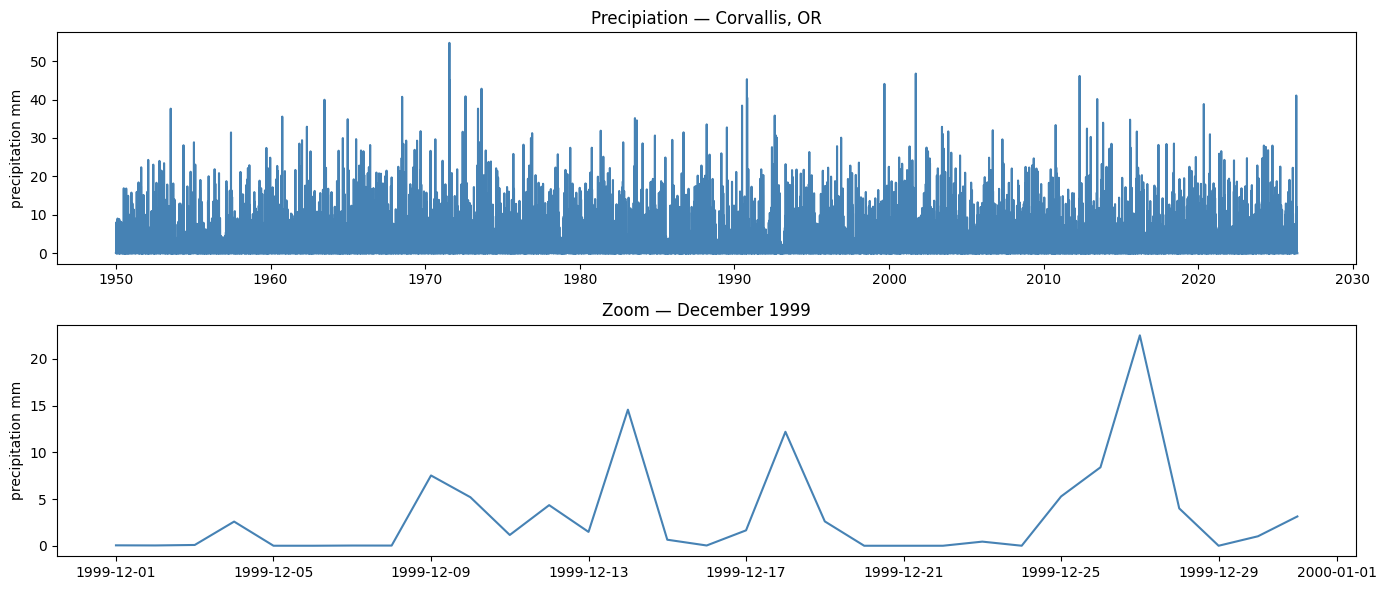

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Serie completa
axes[0].plot(data.index, data['precipitation_mm'], color='steelblue')
axes[0].set_ylabel('precipitation mm')
axes[0].set_title('Precipiation — Corvallis, OR')

# Zoom a un mes de invierno
one_month = data[(data.index >= '1999-12-01') & (data.index < '2000-01-01')]
axes[1].plot(one_month.index, one_month['precipitation_mm'],  color='steelblue')
axes[1].set_ylabel('precipitation mm')
axes[1].set_title('Zoom — December 1999')

plt.tight_layout()
plt.show()

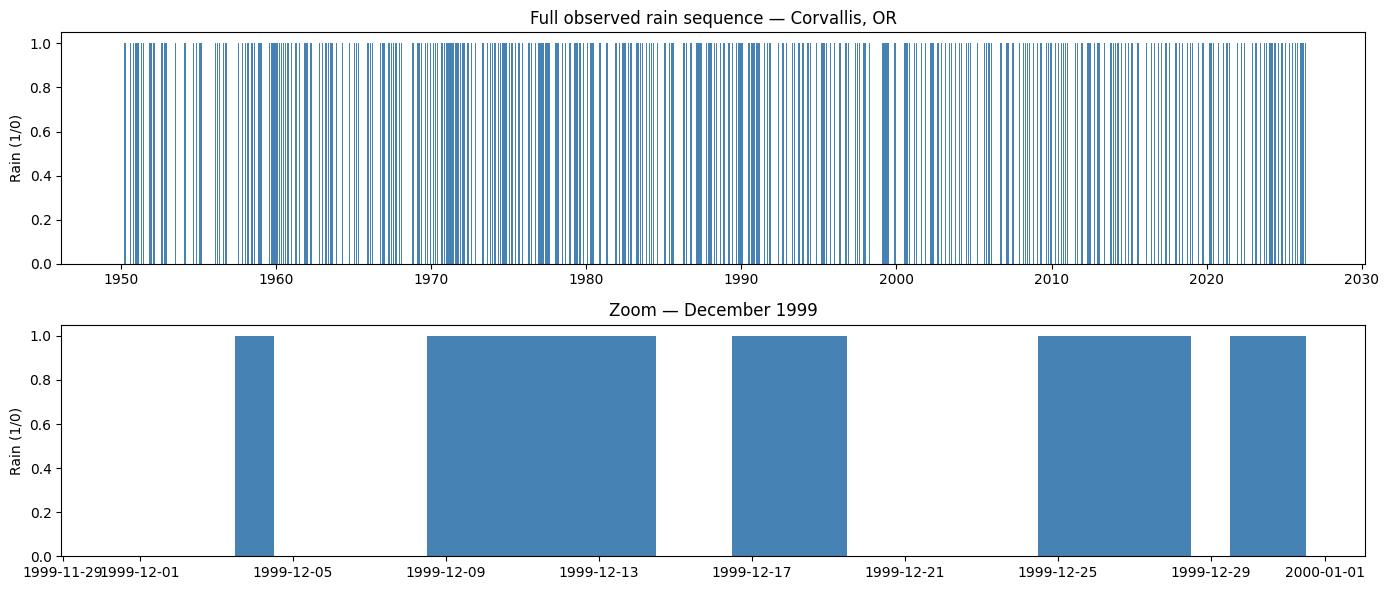

In [63]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Serie completa
axes[0].bar(data.index, data['rain'], width=1, color='steelblue')
axes[0].set_ylabel('Rain (1/0)')
axes[0].set_title('Full observed rain sequence — Corvallis, OR')

# Zoom a un mes de invierno
one_month = data[(data.index >= '1999-12-01') & (data.index < '2000-01-01')]
axes[1].bar(one_month.index, one_month['rain'], width=1, color='steelblue')
axes[1].set_ylabel('Rain (1/0)')
axes[1].set_title('Zoom — December 1999')

plt.tight_layout()
plt.show()

## 02 Transition Probabilities

A Markov chain model works on transition probabilities. That is, the probability that tomorrow rains depends on whether it rained today or not.

In [64]:
prob_table = pd.crosstab(data['rain'], data['rain_next'], normalize='index')
prob_table.index = ['No rain (today)', 'Rain (today)']
prob_table.columns = ['No rain (tomorrow)', 'Rain (tomorrow)']

In [65]:
prob_table

,No rain (tomorrow),Rain (tomorrow)
No rain (today),0.770800,0.229200
Rain (today),0.415935,0.584065


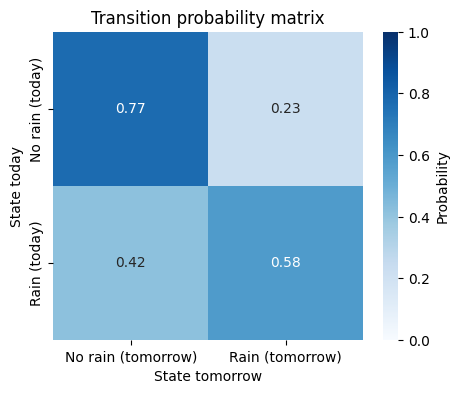

In [66]:
plt.figure(figsize=(5, 4))
sns.heatmap(prob_table, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, cbar_kws={'label': 'Probability'})
plt.title('Transition probability matrix')
plt.ylabel('State today')
plt.xlabel('State tomorrow')
plt.show()

## 03 Simulating Time series

#### 03.1 No memory

We are going to ignore the transition probabilities and do a first simulation with just the overall probability of rainfall, based on the proportion of rainy_days/total_days.

In [67]:
def run_lengths(binary_series):
    # Longitud de cada racha de 1s consecutivos
    runs = []
    count = 0
    for v in binary_series:
        if v == 1:
            count += 1
        else:
            if count > 0:
                runs.append(count)
            count = 0
    if count > 0:
        runs.append(count)
    return runs

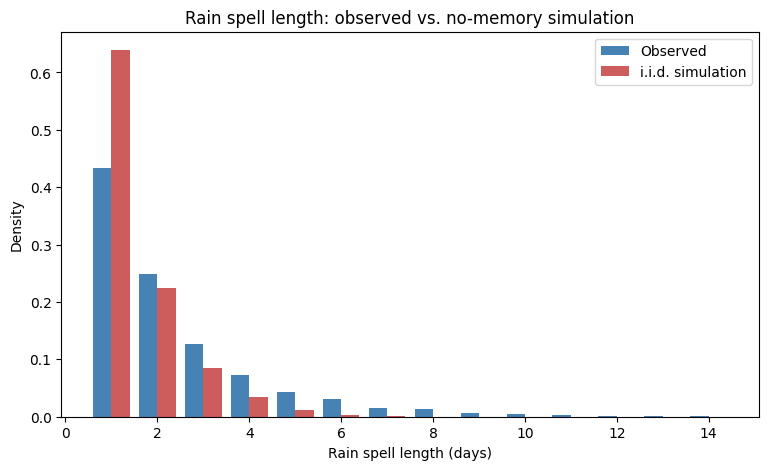

In [68]:
real_runs = run_lengths(data['rain'].values)
iid_full = np.random.binomial(1, p_rain, size=len(data))
iid_runs = run_lengths(iid_full)

bins = np.arange(0.5, 15.5, 1)
bin_centers = np.arange(1, 15)
width = 0.4

real_counts, _ = np.histogram(real_runs, bins=bins, density=True)
iid_counts, _ = np.histogram(iid_runs, bins=bins, density=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(bin_centers - width/2, real_counts, width=width, label='Observed', color='steelblue')
ax.bar(bin_centers + width/2, iid_counts, width=width, label='i.i.d. simulation', color='indianred')

ax.set_xlabel('Rain spell length (days)')
ax.set_ylabel('Density')
ax.set_title('Rain spell length: observed vs. no-memory simulation')
ax.legend()
plt.show()

#### 03.2 With Transition Probabilities

To simulate a Markov chain, we need:

1. An **initial state** for day 1 (rain or no rain).
2. At each following day, draw the next state using the transition probabilities from `prob_table`, based on **today's** state.
3. Repeat for the desired number of days.

In [69]:
length = len(data)
seed_mk = 0  # no rain, initial state for day 1

In [70]:
def simulate_markov(prob_table, length, initial_state, seed):
    rng = np.random.default_rng(seed)
    states = np.zeros(length, dtype=int)
    states[0] = initial_state
    
    for t in range(1, length):
        # P(rain tomorrow | today's state) -> column index 1 = "Rain (tomorrow)"
        p_rain_next = prob_table.iloc[states[t-1], 1]
        states[t] = rng.binomial(1, p_rain_next)
    
    return states

markov_sim = simulate_markov(prob_table, length, seed_mk, seed=156)

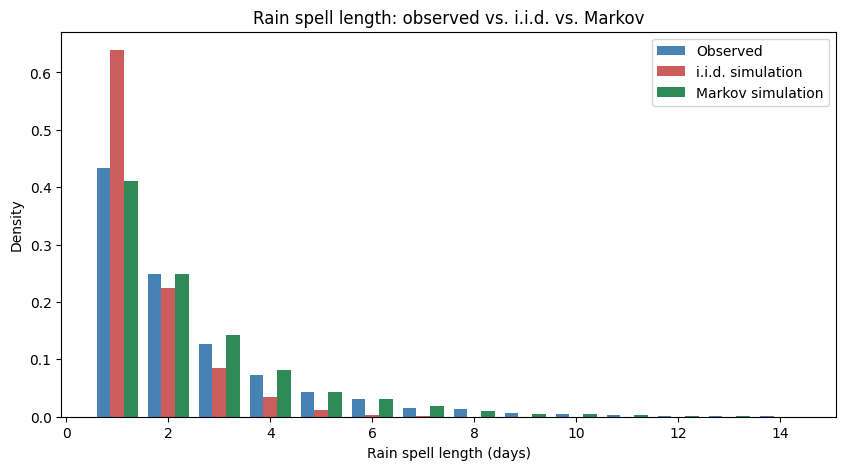

In [71]:
markov_runs = run_lengths(markov_sim)

bins = np.arange(0.5, 15.5, 1)
bin_centers = np.arange(1, 15)
width = 0.27

real_counts, _ = np.histogram(real_runs, bins=bins, density=True)
iid_counts, _ = np.histogram(iid_runs, bins=bins, density=True)
markov_counts, _ = np.histogram(markov_runs, bins=bins, density=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bin_centers - width, real_counts, width=width, label='Observed', color='steelblue')
ax.bar(bin_centers, iid_counts, width=width, label='i.i.d. simulation', color='indianred')
ax.bar(bin_centers + width, markov_counts, width=width, label='Markov simulation', color='seagreen')

ax.set_xlabel('Rain spell length (days)')
ax.set_ylabel('Density')
ax.set_title('Rain spell length: observed vs. i.i.d. vs. Markov')
ax.legend()

What if we had more days of memory?

In [72]:
data = data.copy()
data['rain_lag1'] = data['rain'].shift(1)
data['rain_lag2'] = data['rain'].shift(2)

order2 = data.dropna(subset=['rain_lag1', 'rain_lag2'])

prob_table_order2 = order2.groupby(['rain_lag2', 'rain_lag1'])['rain'].mean()
prob_table_order2

rain_lag2  rain_lag1
0.0        0.0          0.206894
           1.0          0.566925
1.0        0.0          0.304316
           1.0          0.596270
Name: rain, dtype: float64

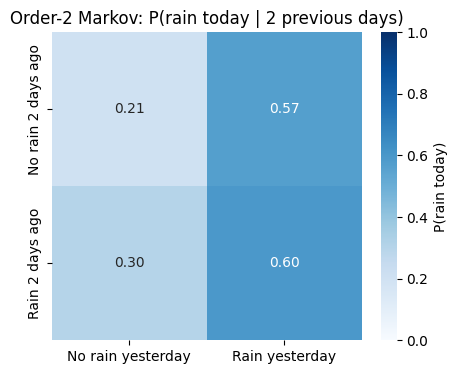

In [73]:
prob_table_order2_wide = prob_table_order2.unstack()
prob_table_order2_wide.index = ['No rain 2 days ago', 'Rain 2 days ago']
prob_table_order2_wide.columns = ['No rain yesterday', 'Rain yesterday']

plt.figure(figsize=(5, 4))
sns.heatmap(prob_table_order2_wide, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, cbar_kws={'label': 'P(rain today)'})
plt.title('Order-2 Markov: P(rain today | 2 previous days)')
plt.show()

In [74]:
markov_df = pd.DataFrame({'rain': markov_sim}, index=data.index)
markov_df['week'] = data.index.isocalendar().week
markov_df['doy'] = data.index.dayofyear
markov_df['month'] = data.index.month

In [75]:
data['week'] = data.index.isocalendar().week
markov_df['week'] = data['week'].values

weekly_observed = data.groupby('week')['rain'].mean()
weekly_markov = markov_df.groupby('week')['rain'].mean()

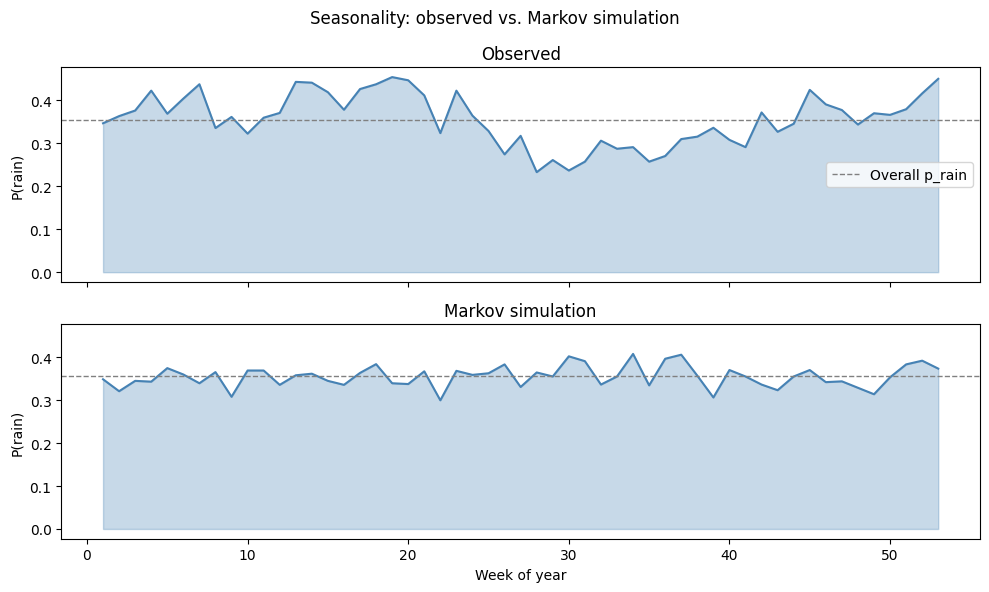

In [76]:
weekly_observed = data.groupby('week')['rain'].mean()
weekly_markov = markov_df.groupby('week')['rain'].mean()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)

color = 'steelblue'

axes[0].plot(weekly_observed.index, weekly_observed.values, color=color, linewidth=1.5)
axes[0].fill_between(weekly_observed.index, weekly_observed.values, color=color, alpha=0.3)
axes[0].axhline(p_rain, color='gray', linestyle='--', linewidth=1, label='Overall p_rain')
axes[0].set_ylabel('P(rain)')
axes[0].set_title('Observed')
axes[0].legend()

axes[1].plot(weekly_markov.index, weekly_markov.values, color=color, linewidth=1.5)
axes[1].fill_between(weekly_markov.index, weekly_markov.values, color=color, alpha=0.3)
axes[1].axhline(p_rain, color='gray', linestyle='--', linewidth=1, label='Overall p_rain')
axes[1].set_ylabel('P(rain)')
axes[1].set_xlabel('Week of year')
axes[1].set_title('Markov simulation')

fig.suptitle('Seasonality: observed vs. Markov simulation')
plt.tight_layout()
plt.show()